1. Imports

In [1]:
import torch
import torch.nn as nn
from torchdiffeq import odeint
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt

torch.manual_seed(42)
np.random.seed(42)



2. Generate dataset
* solve_ivp on the geodesic system 
* sample 1000 initial conditions 
* verify with a plot

In [2]:
def geodesic_rhs(t, state):
    x, y, theta = state
    r2 = x**2 + y**2
    x_dot = (1-r2)/2 *np.cos(theta)
    y_dot = (1-r2)/2 *np.sin(theta)
    theta_dot = y *np.cos(theta)-x*np.sin(theta)
    return [x_dot, y_dot, theta_dot]

N = 1000
states_0 = np.zeros((N, 3))
states_target = np.zeros((N, 3))

for i in range(N):
    r = 0.8 * np.sqrt(np.random.uniform(0, 1))
    phi = np.random.uniform(0, 2 * np.pi)
    x0 = r * np.cos(phi)
    y0 = r * np.sin(phi)
    theta0 = np.random.uniform(0, 2*np.pi)
    sol = solve_ivp(geodesic_rhs, t_span=(0, 1.0), y0=[x0, y0, theta0],
                    method='RK45', rtol=1e-8, t_eval=np.linspace(0,1,50))
    states_0[i] = [x0, y0, theta0]  
    states_target[i] = sol.y[:, -1]

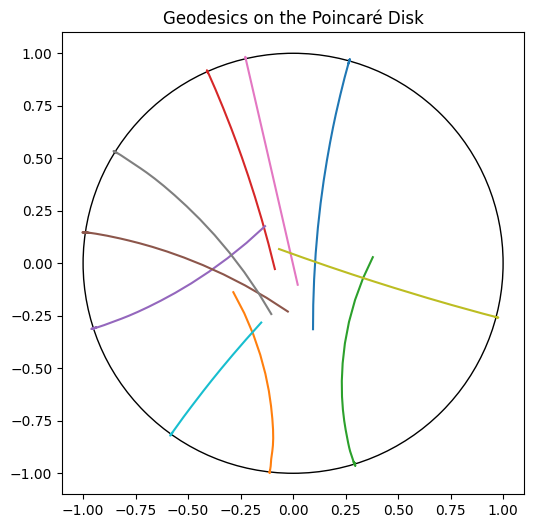

In [3]:
fig, ax = plt.subplots(figsize=(6,6))
circle = plt.Circle((0,0), 1, fill=False, color='black')
ax.add_patch(circle)
t_eval_plot = np.linspace(0, 50, 200)
for _ in range(10):
    r = 0.4 * np.sqrt(np.random.uniform(0, 1))
    phi = np.random.uniform(0, 2*np.pi)
    x0 = r * np.cos(phi)
    y0 = r * np.sin(phi)
    theta0 = np.random.uniform(0, 2*np.pi)
    sol = solve_ivp(geodesic_rhs, t_span=(0, 50), y0=[x0, y0, theta0],
                    method='RK45', rtol=1e-2, t_eval=t_eval_plot)
    ax.plot(sol.y[0], sol.y[1]) 

ax.set_xlim(-1.1, 1.1)
ax.set_ylim(-1.1, 1.1)
ax.set_aspect('equal')
ax.set_title('Geodesics on the Poincaré Disk')
plt.savefig("figures/true_trajectory.png", dpi=300)
plt.show()

3. Define the Neural ODE and train the model to generate trajectories

In [4]:
class ODEfunc(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
        nn.Linear(3, 64),
        nn.Tanh(),
        nn.Linear(64, 64),
        nn.Tanh(),
        nn.Linear(64, 3)
    )
    def forward(self,t,x):
        return self.net(x)

func = ODEfunc()
optimizer = torch.optim.Adam(func.parameters(), lr=1e-3)
criterion = nn.MSELoss()

epochs = 1000
t= torch.tensor([0.0, 1.0])
states_target_tensor = torch.tensor(states_target, dtype=torch.float32)
for epoch in range(epochs):
    optimizer.zero_grad()
    x_pred = odeint(func, torch.tensor(states_0, dtype=torch.float32), t)
    loss = criterion(x_pred[-1], states_target_tensor)
    loss.backward()
    optimizer.step()
    if epoch % 100 == 0:
        print(f"Epoch {epoch}, Loss: {loss.item():.4f}")

Epoch 0, Loss: 0.1084
Epoch 100, Loss: 0.0376
Epoch 200, Loss: 0.0152
Epoch 300, Loss: 0.0079
Epoch 400, Loss: 0.0049
Epoch 500, Loss: 0.0032
Epoch 600, Loss: 0.0023
Epoch 700, Loss: 0.0018
Epoch 800, Loss: 0.0015
Epoch 900, Loss: 0.0012


4. Evaluate the model
* overlay predicted vs true trajectories on the Poincaré disk

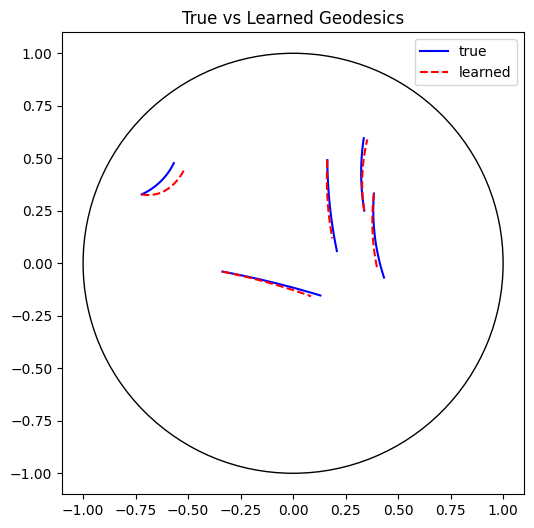

In [5]:
fig, ax = plt.subplots(figsize=(6,6))
circle = plt.Circle((0,0), 1, fill=False, color='black')
ax.add_patch(circle)

t_plot = np.linspace(0, 1.0, 50)
t_plot_torch = torch.tensor(t_plot, dtype=torch.float32)

for _ in range(5):
    phi = np.random.uniform(0, 2 * np.pi)
    r = 0.8 * np.sqrt(np.random.uniform(0, 1))
    x0 = r * np.cos(phi)
    y0 = r * np.sin(phi)
    theta0 = np.random.uniform(0, 2*np.pi)
    states_0 = x0, y0, theta0
    
    True_geodesic = solve_ivp(geodesic_rhs, t_span=(0, 1.0), y0=[x0, y0, theta0],
                    method='RK45', rtol=1e-8, t_eval=np.linspace(0,1,50))
    ax.plot(True_geodesic.y[0], True_geodesic.y[1], color='blue',label='true'if _ == 0 else '')  

    Learned_geodesic = odeint(func, torch.tensor(states_0, dtype=torch.float32), t_plot_torch)
    ax.plot(Learned_geodesic[:, 0].detach().numpy(),  Learned_geodesic[:, 1].detach().numpy(), color='red', linestyle='--',label='learned' if _ == 0 else '')

ax.set_xlim(-1.1, 1.1)
ax.set_ylim(-1.1, 1.1)
ax.set_aspect('equal')
ax.set_title('True vs Learned Geodesics')
ax.legend()
plt.savefig("figures/trajectory_overlay.png", dpi=300)
plt.show()

5. Save model

In [6]:
torch.save(func.state_dict(), "models/geodesic_node.pt")